# Ablation: Extreme Scenarios WITHOUT Decoder

This notebook tests the pipeline on extreme-criticality scenarios **without the
Hierarchical Feasibility Decoder**. Raw EBM binary samples are passed directly
to the LP Worker Two-Stage, bypassing the decoder's greedy heuristic.

**Goal**: Determine whether the decoder degrades the EBM's binary decisions
and contributes to the large cost gap observed in `evaluation_extreme.ipynb`.

**Comparison baseline**: Results from `evaluation_extreme.ipynb` (with decoder).

**Prerequisites**:
- `outputs/extreme_criticality_scenarios/` with 100 scenarios + MILP reports
- `outputs/pipeline_eval_extreme/pipeline_eval_extreme.pkl` (baseline results)
- Models: `best_encoder.pt`, `ebm_v3_final.pt`

## 1. Install Dependencies

In [1]:
import subprocess, sys

print('Installing PyTorch 2.5.1 and PyTorch Geometric...')

subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y',
    'torch', 'torchvision', 'torchaudio', 'torch-scatter', 'torch-sparse', 'torch-geometric'],
    capture_output=True)

!pip install -q torch==2.5.1+cu124 torchvision==0.20.1+cu124 torchaudio==2.5.1+cu124 --index-url https://download.pytorch.org/whl/cu124
!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.5.1+cu124.html
!pip install -q torch-geometric
!pip install -q numpy scipy tqdm pandas matplotlib seaborn scikit-learn pyomo highspy thrml

print('Dependencies installed')

Installing PyTorch 2.5.1 and PyTorch Geometric...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 59.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 66.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 113.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 145.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 45.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.8

## 2. Mount Drive & Setup Paths

In [1]:
import importlib, sys

modules_to_clear = [m for m in sys.modules if m.startswith('src.')]
for m in modules_to_clear:
    del sys.modules[m]
print(f'Cleared {len(modules_to_clear)} cached modules')

Cleared 0 cached modules


In [2]:
import os, sys, json, time, pickle
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any
from tqdm.auto import tqdm
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

REPO_PATH = Path('/content/drive/MyDrive/benchmark')
sys.path.insert(0, str(REPO_PATH))
os.chdir(REPO_PATH)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Repo: {REPO_PATH}')
print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

Mounted at /content/drive
Repo: /content/drive/MyDrive/benchmark
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [3]:
import shutil, glob

pycache_dirs = glob.glob(str(REPO_PATH / 'src/**/__pycache__'), recursive=True)
for d in pycache_dirs:
    shutil.rmtree(d)
print(f'Purged {len(pycache_dirs)} __pycache__ directories')

# Verify skip_decoder flag exists
runner_src = (REPO_PATH / 'src/eval/pipeline_runner.py').read_text(encoding='utf-8')
assert 'skip_decoder' in runner_src, 'BUG: skip_decoder flag missing from pipeline_runner!'
print('skip_decoder flag verified')

Purged 9 __pycache__ directories
skip_decoder flag verified


## 3. Configuration

In [4]:
EXTREME_DIR = REPO_PATH / 'outputs/extreme_criticality_scenarios'
REPORTS_DIR = EXTREME_DIR / 'reports'
OUTPUT_DIR  = REPO_PATH / 'outputs/pipeline_eval_extreme_no_decoder'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Baseline results (with decoder)
BASELINE_PKL = REPO_PATH / 'outputs/pipeline_eval_extreme/pipeline_eval_extreme.pkl'

sc_count = len(list(EXTREME_DIR.glob('scenario_*.json')))
rp_count = len(list(REPORTS_DIR.glob('scenario_*.json'))) if REPORTS_DIR.exists() else 0
print(f'Extreme scenarios: {sc_count}')
print(f'MILP reports:      {rp_count}')
print(f'Baseline exists:   {BASELINE_PKL.exists()}')

Extreme scenarios: 100
MILP reports:      100
Baseline exists:   True


## 4. Run Pipeline WITHOUT Decoder

Key difference: `skip_decoder=True` passes raw EBM binary samples `[Z, T, 7]`
directly to the LP Worker, with no feasibility projection and no warm-start.

In [7]:
from src.eval.pipeline_runner import PipelineConfig, PipelineRunner

config = PipelineConfig(
    repo_path=str(REPO_PATH),
    encoder_path='outputs/encoders/hierarchical_temporal_v3/best_encoder.pt',
    ebm_path='outputs/ebm_models/ebm_v3/ebm_v3_final.pt',
    node_feature_dim=14,
    hidden_dim=128,
    num_spatial_layers=2,
    num_temporal_layers=4,
    num_heads=8,
    dropout=0.1,
    embed_dim=128,
    n_features=7,
    n_timesteps=24,
    langevin_steps=100,
    step_size=0.05,
    noise_scale=0.5,
    init_temp=1.0,
    final_temp=0.1,
    n_samples=5,
    solver_name='appsi_highs',
    skip_decoder=True,          # <--- ABLATION: bypass decoder
    device=DEVICE,
    seed=42,
)

torch.manual_seed(config.seed)
np.random.seed(config.seed)

print(f'skip_decoder = {config.skip_decoder}')

runner = PipelineRunner(config)
runner.load_models()

skip_decoder = True
Loading HTE encoder...
  Encoder loaded: 3,185,664 params
Loading EBM v3...
  EBM loaded: 553,729 params
  Sampler ready (infer mode)


In [6]:
import shutil

graphs_dir = OUTPUT_DIR / 'graphs'
if graphs_dir.exists():
    shutil.rmtree(graphs_dir)
    print('Cleared stale graph cache')

results_no_dec = runner.evaluate_family(
    scenarios_dir=EXTREME_DIR,
    reports_dir=REPORTS_DIR,
    graphs_dir=graphs_dir,
    family_name='extreme_no_decoder',
)

runner.save_results(results_no_dec, OUTPUT_DIR / 'pipeline_eval_extreme_no_decoder.pkl')
print(f'\nTotal: {len(results_no_dec)} scenarios evaluated')


Evaluating 100 scenarios from extreme_no_decoder


Pipeline [extreme_no_decoder]:   0%|          | 0/100 [00:00<?, ?it/s]

Saved 100 results to /content/drive/MyDrive/benchmark/outputs/pipeline_eval_extreme_no_decoder/pipeline_eval_extreme_no_decoder.pkl

Total: 100 scenarios evaluated


## 5. Build Comparison DataFrame (No-Decoder)

In [8]:
from src.eval.metrics import compute_eval_metrics, format_metrics_table
from dataclasses import asdict

results_path = OUTPUT_DIR / 'pipeline_eval_extreme_no_decoder.pkl'
if results_path.exists():
    nd_pipeline = PipelineRunner.load_results(results_path)
else:
    nd_pipeline = [asdict(r) for r in results_no_dec]

# compute_eval_metrics expects family key to match reports dir
# Remap family name to 'extreme' so it finds the reports
for r in nd_pipeline:
    r['family'] = 'extreme'

milp_reports_dirs = {'extreme': REPORTS_DIR}
eval_nd = compute_eval_metrics(nd_pipeline, milp_reports_dirs)
df_nd = eval_nd['dataframe']

print(f'DataFrame: {df_nd.shape}')
print(f'Success rate: {df_nd["success"].mean()*100:.1f}%')
print()
print(format_metrics_table(eval_nd['global'], 'Extreme - NO DECODER'))

DataFrame: (100, 26)
Success rate: 100.0%


  Extreme - NO DECODER Evaluation Metrics

  cost_gap_pct:
    Mean: 578.99 (std: 4074.35)
    Median: -0.40
    [P10, P90]: [-3.74, 169.91]
    [P95, P99]: [669.81, 12656.23]

  speedup:
    Mean: 2.32 (std: 0.90)
    Median: 2.04
    [P10, P90]: [1.48, 3.82]
    [P95, P99]: [4.16, 4.84]

  pipeline_time_s:
    Mean: 590.15 (std: 200.53)
    Median: 590.88
    [P10, P90]: [316.31, 817.11]
    [P95, P99]: [884.45, 1001.36]

  slack_mwh:
    Mean: 11.90 (std: 86.58)
    Median: 0.00
    [P10, P90]: [0.00, 0.00]
    [P95, P99]: [0.00, 442.35]

  Stage Distribution:
    full_soft: 79.0%
    repair_20: 19.0%
    repair_100: 2.0%


## 6. Load Baseline (With Decoder) for Comparison

In [9]:
HAS_BASELINE = BASELINE_PKL.exists()

if HAS_BASELINE:
    baseline_pipeline = PipelineRunner.load_results(BASELINE_PKL)
    eval_bl = compute_eval_metrics(baseline_pipeline, milp_reports_dirs)
    df_bl = eval_bl['dataframe']
    print(f'Baseline loaded: {len(df_bl)} scenarios')
    print()
    print(format_metrics_table(eval_bl['global'], 'Extreme - WITH DECODER (baseline)'))
else:
    print('Baseline results not found - run evaluation_extreme.ipynb first')
    df_bl = None

Baseline loaded: 100 scenarios


  Extreme - WITH DECODER (baseline) Evaluation Metrics

  cost_gap_pct:
    Mean: 519.63 (std: 2035.12)
    Median: 119.63
    [P10, P90]: [58.42, 602.21]
    [P95, P99]: [1420.36, 6885.96]

  speedup:
    Mean: 5.82 (std: 1.66)
    Median: 5.41
    [P10, P90]: [3.86, 8.19]
    [P95, P99]: [8.47, 9.33]

  pipeline_time_s:
    Mean: 224.87 (std: 65.42)
    Median: 223.38
    [P10, P90]: [147.69, 313.15]
    [P95, P99]: [343.37, 438.75]

  slack_mwh:
    Mean: 0.01 (std: 0.09)
    Median: 0.00
    [P10, P90]: [0.00, 0.00]
    [P95, P99]: [0.00, 0.01]

  Stage Distribution:
    hard_fix: 48.0%
    repair_20: 46.0%
    full_soft: 6.0%


## 7. Head-to-Head Comparison

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

if HAS_BASELINE:
    # Merge on scenario_id
    df_cmp = df_nd[['scenario_id', 'pipeline_objective', 'pipeline_solve_time',
                     'pipeline_stage', 'pipeline_n_flips', 'cost_gap_pct',
                     'speedup', 'time_decoder', 'time_lp_solve',
                     'milp_objective', 'milp_solve_time']].copy()
    df_cmp.columns = ['scenario_id', 'nd_objective', 'nd_solve_time',
                      'nd_stage', 'nd_n_flips', 'nd_cost_gap',
                      'nd_speedup', 'nd_time_decoder', 'nd_time_lp',
                      'milp_objective', 'milp_solve_time']

    bl_cols = df_bl[['scenario_id', 'pipeline_objective', 'pipeline_solve_time',
                     'pipeline_stage', 'pipeline_n_flips', 'cost_gap_pct',
                     'speedup', 'time_decoder', 'time_lp_solve']].copy()
    bl_cols.columns = ['scenario_id', 'bl_objective', 'bl_solve_time',
                       'bl_stage', 'bl_n_flips', 'bl_cost_gap',
                       'bl_speedup', 'bl_time_decoder', 'bl_time_lp']

    df_cmp = df_cmp.merge(bl_cols, on='scenario_id', how='inner')
    print(f'Matched scenarios: {len(df_cmp)}')

    # Who wins per scenario?
    df_cmp['nd_wins'] = df_cmp['nd_objective'] < df_cmp['bl_objective']
    df_cmp['bl_wins'] = df_cmp['bl_objective'] < df_cmp['nd_objective']
    df_cmp['tie'] = df_cmp['nd_objective'] == df_cmp['bl_objective']

    nd_win = df_cmp['nd_wins'].sum()
    bl_win = df_cmp['bl_wins'].sum()
    ties = df_cmp['tie'].sum()
    print(f'\nNo-Decoder wins: {nd_win}/{len(df_cmp)}  ({nd_win/len(df_cmp)*100:.0f}%)')
    print(f'With-Decoder wins: {bl_win}/{len(df_cmp)}  ({bl_win/len(df_cmp)*100:.0f}%)')
    print(f'Ties: {ties}/{len(df_cmp)}')
else:
    print('Skipping comparison (no baseline)')

Matched scenarios: 100

No-Decoder wins: 79/100  (79%)
With-Decoder wins: 21/100  (21%)
Ties: 0/100


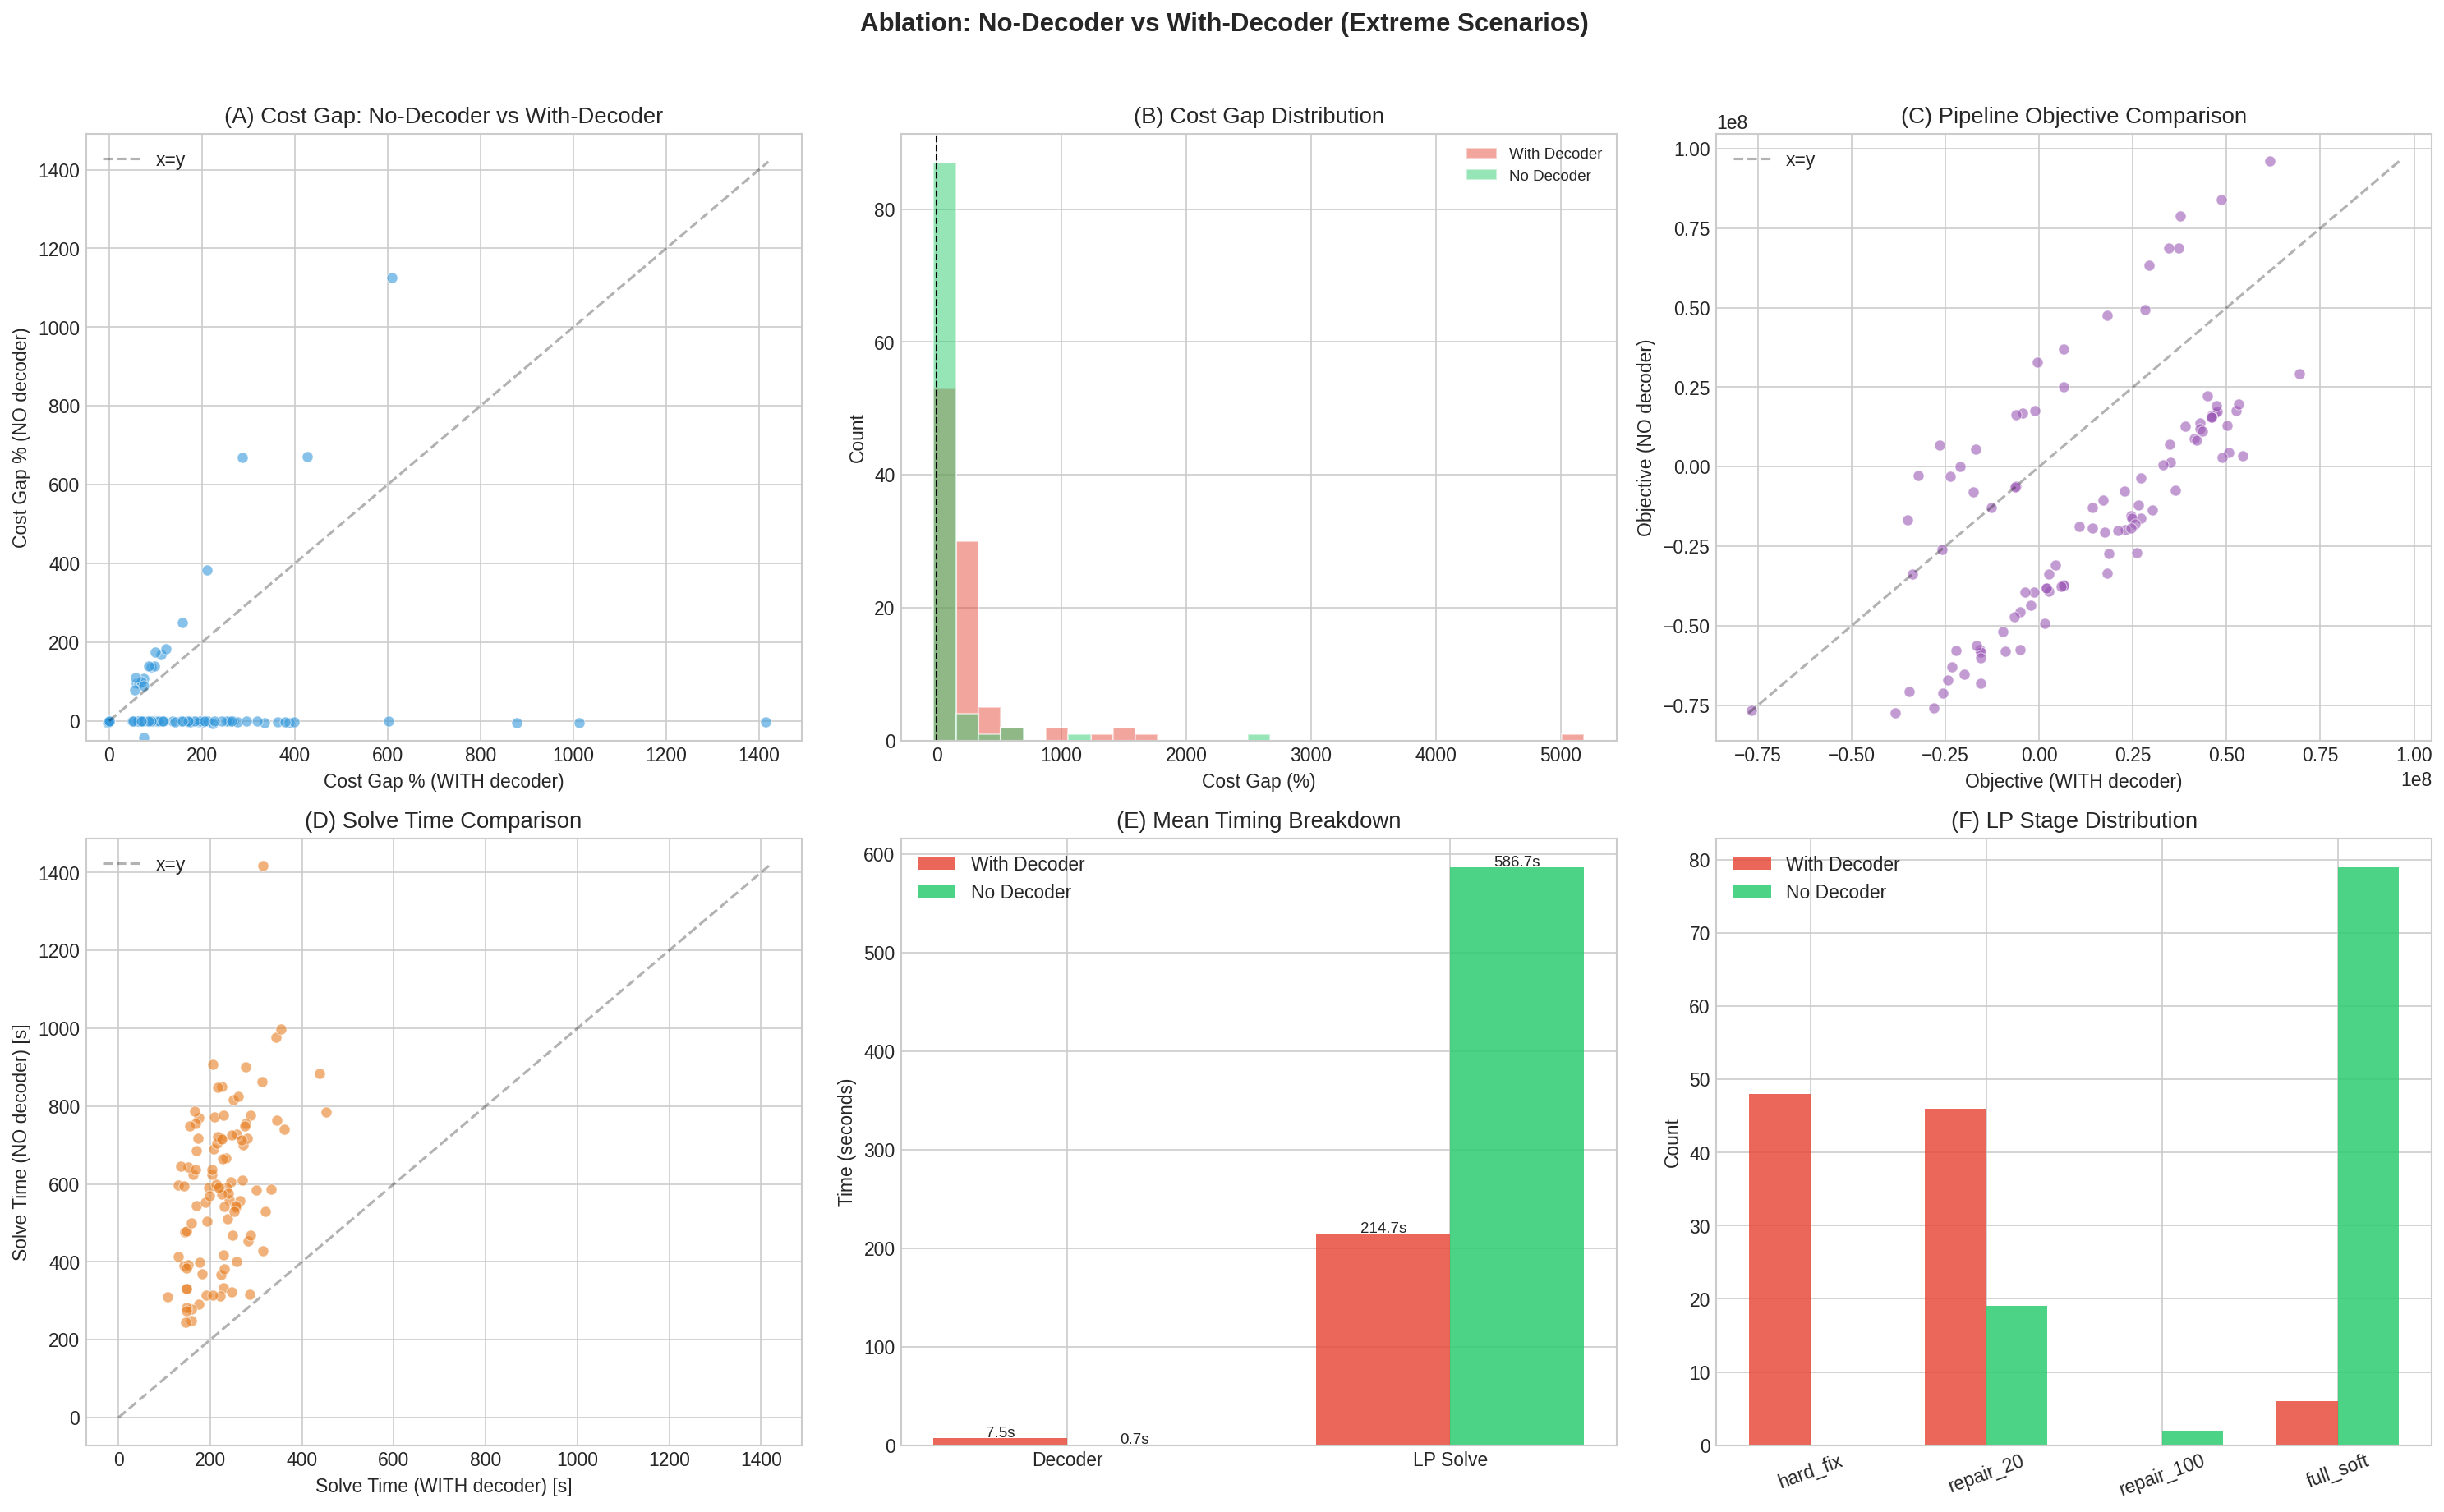

In [11]:
if HAS_BASELINE:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))

    # ── Panel A: Cost gap comparison (paired scatter) ──
    ax = axes[0, 0]
    ax.scatter(df_cmp['bl_cost_gap'], df_cmp['nd_cost_gap'],
              c='#3498db', s=40, alpha=0.6, edgecolors='white', linewidth=0.5)
    lim = max(df_cmp['bl_cost_gap'].quantile(0.95), df_cmp['nd_cost_gap'].quantile(0.95))
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='x=y')
    ax.set_xlabel('Cost Gap % (WITH decoder)')
    ax.set_ylabel('Cost Gap % (NO decoder)')
    ax.set_title('(A) Cost Gap: No-Decoder vs With-Decoder')
    ax.legend()
    # Clip to 95th percentile for readability
    ax.set_xlim(-50, lim * 1.05)
    ax.set_ylim(-50, lim * 1.05)

    # ── Panel B: Cost gap distributions ──
    ax = axes[0, 1]
    bins = np.linspace(
        min(df_cmp['bl_cost_gap'].quantile(0.02), df_cmp['nd_cost_gap'].quantile(0.02)),
        max(df_cmp['bl_cost_gap'].quantile(0.98), df_cmp['nd_cost_gap'].quantile(0.98)),
        30
    )
    ax.hist(df_cmp['bl_cost_gap'], bins=bins, alpha=0.5, color='#e74c3c',
            label='With Decoder', edgecolor='white')
    ax.hist(df_cmp['nd_cost_gap'], bins=bins, alpha=0.5, color='#2ecc71',
            label='No Decoder', edgecolor='white')
    ax.axvline(x=0, color='black', linestyle='--', lw=1)
    ax.set_xlabel('Cost Gap (%)')
    ax.set_ylabel('Count')
    ax.set_title('(B) Cost Gap Distribution')
    ax.legend(fontsize=9)

    # ── Panel C: Objective scatter ──
    ax = axes[0, 2]
    ax.scatter(df_cmp['bl_objective'], df_cmp['nd_objective'],
              c='#9b59b6', s=40, alpha=0.6, edgecolors='white', linewidth=0.5)
    obj_min = min(df_cmp['bl_objective'].min(), df_cmp['nd_objective'].min())
    obj_max = max(df_cmp['bl_objective'].max(), df_cmp['nd_objective'].max())
    ax.plot([obj_min, obj_max], [obj_min, obj_max], 'k--', alpha=0.3, label='x=y')
    ax.set_xlabel('Objective (WITH decoder)')
    ax.set_ylabel('Objective (NO decoder)')
    ax.set_title('(C) Pipeline Objective Comparison')
    ax.legend()

    # ── Panel D: Solve time comparison ──
    ax = axes[1, 0]
    ax.scatter(df_cmp['bl_solve_time'], df_cmp['nd_solve_time'],
              c='#e67e22', s=40, alpha=0.6, edgecolors='white', linewidth=0.5)
    t_max = max(df_cmp['bl_solve_time'].max(), df_cmp['nd_solve_time'].max())
    ax.plot([0, t_max], [0, t_max], 'k--', alpha=0.3, label='x=y')
    ax.set_xlabel('Solve Time (WITH decoder) [s]')
    ax.set_ylabel('Solve Time (NO decoder) [s]')
    ax.set_title('(D) Solve Time Comparison')
    ax.legend()

    # ── Panel E: Timing breakdown comparison ──
    ax = axes[1, 1]
    labels = ['Decoder', 'LP Solve']
    bl_means = [df_cmp['bl_time_decoder'].mean(), df_cmp['bl_time_lp'].mean()]
    nd_means = [df_cmp['nd_time_decoder'].mean(), df_cmp['nd_time_lp'].mean()]
    x = np.arange(len(labels))
    w = 0.35
    bars1 = ax.bar(x - w/2, bl_means, w, label='With Decoder', color='#e74c3c', alpha=0.85)
    bars2 = ax.bar(x + w/2, nd_means, w, label='No Decoder', color='#2ecc71', alpha=0.85)
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}s', ha='center', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}s', ha='center', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Time (seconds)')
    ax.set_title('(E) Mean Timing Breakdown')
    ax.legend()

    # ── Panel F: Stage distribution comparison ──
    ax = axes[1, 2]
    stages_order = ['hard_fix', 'repair_20', 'repair_100', 'full_soft', 'failed']
    bl_stages = df_cmp['bl_stage'].value_counts()
    nd_stages = df_cmp['nd_stage'].value_counts()
    stage_labels = [s for s in stages_order if s in bl_stages.index or s in nd_stages.index]
    bl_vals = [bl_stages.get(s, 0) for s in stage_labels]
    nd_vals = [nd_stages.get(s, 0) for s in stage_labels]
    x = np.arange(len(stage_labels))
    ax.bar(x - w/2, bl_vals, w, label='With Decoder', color='#e74c3c', alpha=0.85)
    ax.bar(x + w/2, nd_vals, w, label='No Decoder', color='#2ecc71', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(stage_labels, rotation=20)
    ax.set_ylabel('Count')
    ax.set_title('(F) LP Stage Distribution')
    ax.legend()

    fig.suptitle('Ablation: No-Decoder vs With-Decoder (Extreme Scenarios)',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig1_no_decoder_vs_decoder.png', dpi=300, bbox_inches='tight')
    plt.show()

## 8. Summary Statistics

In [12]:
if HAS_BASELINE:
    print('=' * 80)
    print('ABLATION SUMMARY: No-Decoder vs With-Decoder (Extreme Scenarios)')
    print('=' * 80)

    metrics = {
        'Cost Gap % (median)': (df_cmp['nd_cost_gap'].median(), df_cmp['bl_cost_gap'].median()),
        'Cost Gap % (mean)':   (df_cmp['nd_cost_gap'].mean(), df_cmp['bl_cost_gap'].mean()),
        'Cost Gap % (P10)':    (np.percentile(df_cmp['nd_cost_gap'].dropna(), 10),
                                np.percentile(df_cmp['bl_cost_gap'].dropna(), 10)),
        'Cost Gap % (P90)':    (np.percentile(df_cmp['nd_cost_gap'].dropna(), 90),
                                np.percentile(df_cmp['bl_cost_gap'].dropna(), 90)),
        'Solve Time (median)': (df_cmp['nd_solve_time'].median(), df_cmp['bl_solve_time'].median()),
        'Solve Time (mean)':   (df_cmp['nd_solve_time'].mean(), df_cmp['bl_solve_time'].mean()),
        'Speedup (median)':    (df_cmp['nd_speedup'].median(), df_cmp['bl_speedup'].median()),
        'LP Time (mean)':      (df_cmp['nd_time_lp'].mean(), df_cmp['bl_time_lp'].mean()),
        'Decoder Time (mean)': (df_cmp['nd_time_decoder'].mean(), df_cmp['bl_time_decoder'].mean()),
    }

    print(f'{"Metric":<25s}  {"No Decoder":>14s}  {"With Decoder":>14s}  {"Delta":>14s}')
    print('-' * 80)
    for name, (nd_val, bl_val) in metrics.items():
        delta = nd_val - bl_val
        sign = '+' if delta > 0 else ''
        print(f'{name:<25s}  {nd_val:>14.2f}  {bl_val:>14.2f}  {sign}{delta:>13.2f}')

    print()
    nd_win = df_cmp['nd_wins'].sum()
    bl_win = df_cmp['bl_wins'].sum()
    print(f'No-Decoder wins (lower cost):    {nd_win}/{len(df_cmp)} ({nd_win/len(df_cmp)*100:.0f}%)')
    print(f'With-Decoder wins (lower cost):  {bl_win}/{len(df_cmp)} ({bl_win/len(df_cmp)*100:.0f}%)')

    # Scenarios where pipeline beats MILP
    nd_beats_milp = (df_cmp['nd_cost_gap'] < 0).sum()
    bl_beats_milp = (df_cmp['bl_cost_gap'] < 0).sum()
    print(f'\nBeats MILP (cost_gap < 0): No-Dec={nd_beats_milp}  vs  With-Dec={bl_beats_milp}')

    # Stage shift
    print(f'\nStage distribution:')
    print(f'  With-Decoder: {dict(df_cmp["bl_stage"].value_counts())}')
    print(f'  No-Decoder:   {dict(df_cmp["nd_stage"].value_counts())}')
else:
    # Standalone summary
    print(format_metrics_table(eval_nd['global'], 'Extreme - NO DECODER'))

ABLATION SUMMARY: No-Decoder vs With-Decoder (Extreme Scenarios)
Metric                         No Decoder    With Decoder           Delta
--------------------------------------------------------------------------------
Cost Gap % (median)                 -0.40          119.63        -120.03
Cost Gap % (mean)                  578.99          519.63  +        59.35
Cost Gap % (P10)                    -3.74           58.42         -62.16
Cost Gap % (P90)                   169.91          602.21        -432.30
Solve Time (median)                590.88          223.38  +       367.50
Solve Time (mean)                  590.15          224.87  +       365.28
Speedup (median)                     2.04            5.41          -3.37
LP Time (mean)                     586.74          214.72  +       372.02
Decoder Time (mean)                  0.72            7.53          -6.81

No-Decoder wins (lower cost):    79/100 (79%)
With-Decoder wins (lower cost):  21/100 (21%)

Beats MILP (cost_gap < 0)

## 9. Per-Scenario Delta Analysis

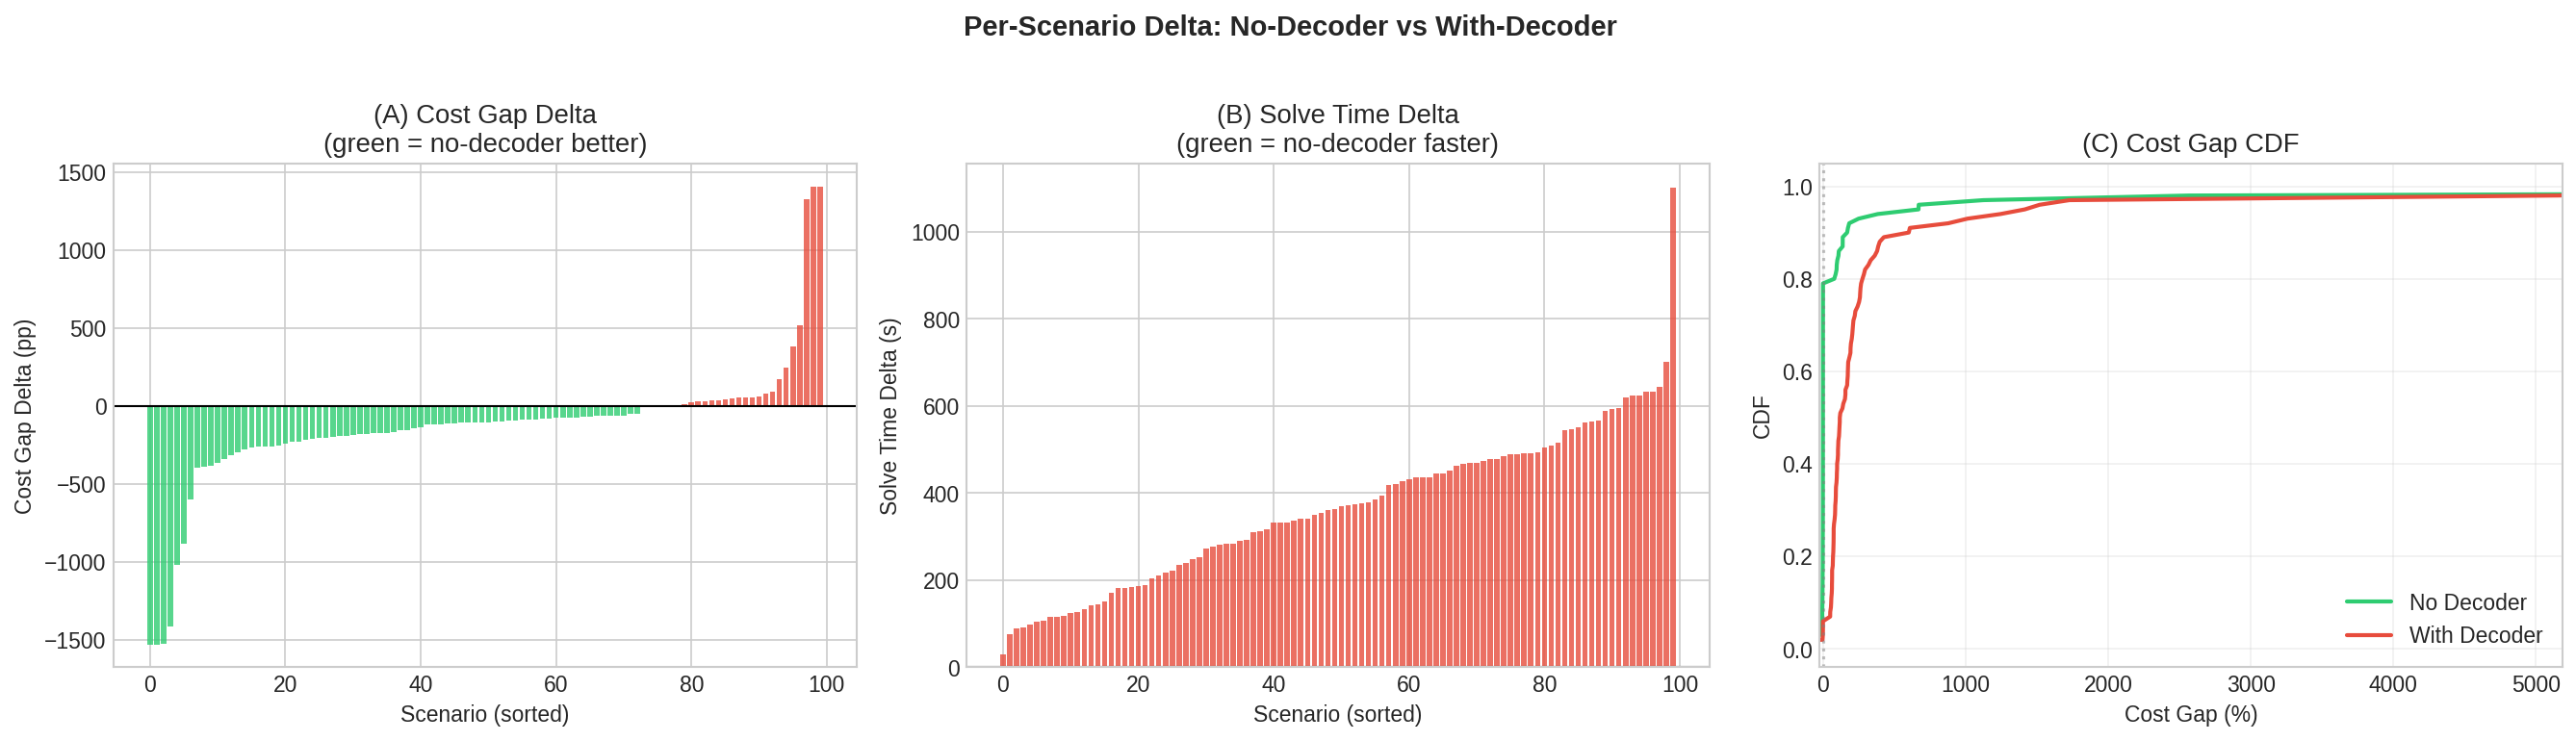

Cost Gap Delta: median=-104.5pp, mean=59.4pp
Time Delta: median=367.5s, mean=365.3s


In [13]:
if HAS_BASELINE:
    # Compute delta: positive = no-decoder is worse, negative = no-decoder is better
    df_cmp['cost_gap_delta'] = df_cmp['nd_cost_gap'] - df_cmp['bl_cost_gap']
    df_cmp['obj_delta'] = df_cmp['nd_objective'] - df_cmp['bl_objective']
    df_cmp['time_delta'] = df_cmp['nd_solve_time'] - df_cmp['bl_solve_time']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel A: Cost gap delta distribution
    ax = axes[0]
    clip_lo = df_cmp['cost_gap_delta'].quantile(0.02)
    clip_hi = df_cmp['cost_gap_delta'].quantile(0.98)
    clipped = df_cmp['cost_gap_delta'].clip(clip_lo, clip_hi)
    colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in clipped]
    ax.bar(range(len(clipped)), clipped.sort_values().values,
           color=['#2ecc71' if v < 0 else '#e74c3c' for v in clipped.sort_values().values],
           alpha=0.8)
    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_xlabel('Scenario (sorted)')
    ax.set_ylabel('Cost Gap Delta (pp)')
    ax.set_title('(A) Cost Gap Delta\n(green = no-decoder better)')

    # Panel B: Time delta
    ax = axes[1]
    sorted_td = df_cmp['time_delta'].sort_values()
    ax.bar(range(len(sorted_td)), sorted_td.values,
           color=['#2ecc71' if v < 0 else '#e74c3c' for v in sorted_td.values],
           alpha=0.8)
    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_xlabel('Scenario (sorted)')
    ax.set_ylabel('Solve Time Delta (s)')
    ax.set_title('(B) Solve Time Delta\n(green = no-decoder faster)')

    # Panel C: Paired cost gap CDF
    ax = axes[2]
    for label, col, color in [('No Decoder', 'nd_cost_gap', '#2ecc71'),
                               ('With Decoder', 'bl_cost_gap', '#e74c3c')]:
        sorted_vals = np.sort(df_cmp[col].dropna().values)
        cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
        ax.plot(sorted_vals, cdf, color=color, lw=2, label=label)
    ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Cost Gap (%)')
    ax.set_ylabel('CDF')
    ax.set_title('(C) Cost Gap CDF')
    ax.legend()
    ax.set_xlim(df_cmp[['nd_cost_gap','bl_cost_gap']].quantile(0.02).min(),
               df_cmp[['nd_cost_gap','bl_cost_gap']].quantile(0.98).max())
    ax.grid(True, alpha=0.3)

    fig.suptitle('Per-Scenario Delta: No-Decoder vs With-Decoder',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig2_per_scenario_delta.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Summary
    print(f'Cost Gap Delta: median={df_cmp["cost_gap_delta"].median():.1f}pp, '
          f'mean={df_cmp["cost_gap_delta"].mean():.1f}pp')
    print(f'Time Delta: median={df_cmp["time_delta"].median():.1f}s, '
          f'mean={df_cmp["time_delta"].mean():.1f}s')

## 10. Detailed Stage Transition Analysis

In [14]:
if HAS_BASELINE:
    # Cross-tabulation: how do stages change when removing decoder?
    print('Stage Transition Matrix (rows=with-decoder, cols=no-decoder):')
    print('Each cell = number of scenarios that moved from row-stage to col-stage')
    print()
    ct = pd.crosstab(df_cmp['bl_stage'], df_cmp['nd_stage'], margins=True)
    print(ct.to_string())

    # For each stage transition, show mean cost gap delta
    print('\nMean cost gap delta by stage transition (negative = no-decoder better):')
    for bl_s in ['hard_fix', 'repair_20', 'full_soft']:
        mask_bl = df_cmp['bl_stage'] == bl_s
        if mask_bl.sum() == 0:
            continue
        for nd_s in ['hard_fix', 'repair_20', 'repair_100', 'full_soft']:
            mask_nd = df_cmp['nd_stage'] == nd_s
            mask = mask_bl & mask_nd
            if mask.sum() > 0:
                delta = df_cmp.loc[mask, 'cost_gap_delta'].mean()
                print(f'  {bl_s:>12s} -> {nd_s:<12s}: n={mask.sum():3d}, '
                      f'mean delta={delta:+.1f}pp')

Stage Transition Matrix (rows=with-decoder, cols=no-decoder):
Each cell = number of scenarios that moved from row-stage to col-stage

nd_stage   full_soft  repair_100  repair_20  All
bl_stage                                        
full_soft          6           0          0    6
hard_fix          35           1         12   48
repair_20         38           1          7   46
All               79           2         19  100

Mean cost gap delta by stage transition (negative = no-decoder better):
      hard_fix -> repair_20   : n= 12, mean delta=+1777.2pp
      hard_fix -> repair_100  : n=  1, mean delta=+92.6pp
      hard_fix -> full_soft   : n= 35, mean delta=-359.1pp
     repair_20 -> repair_20   : n=  7, mean delta=+1090.9pp
     repair_20 -> repair_100  : n=  1, mean delta=+57.0pp
     repair_20 -> full_soft   : n= 38, mean delta=-279.0pp
     full_soft -> full_soft   : n=  6, mean delta=-1.1pp


## 11. Economic Advantage Comparison

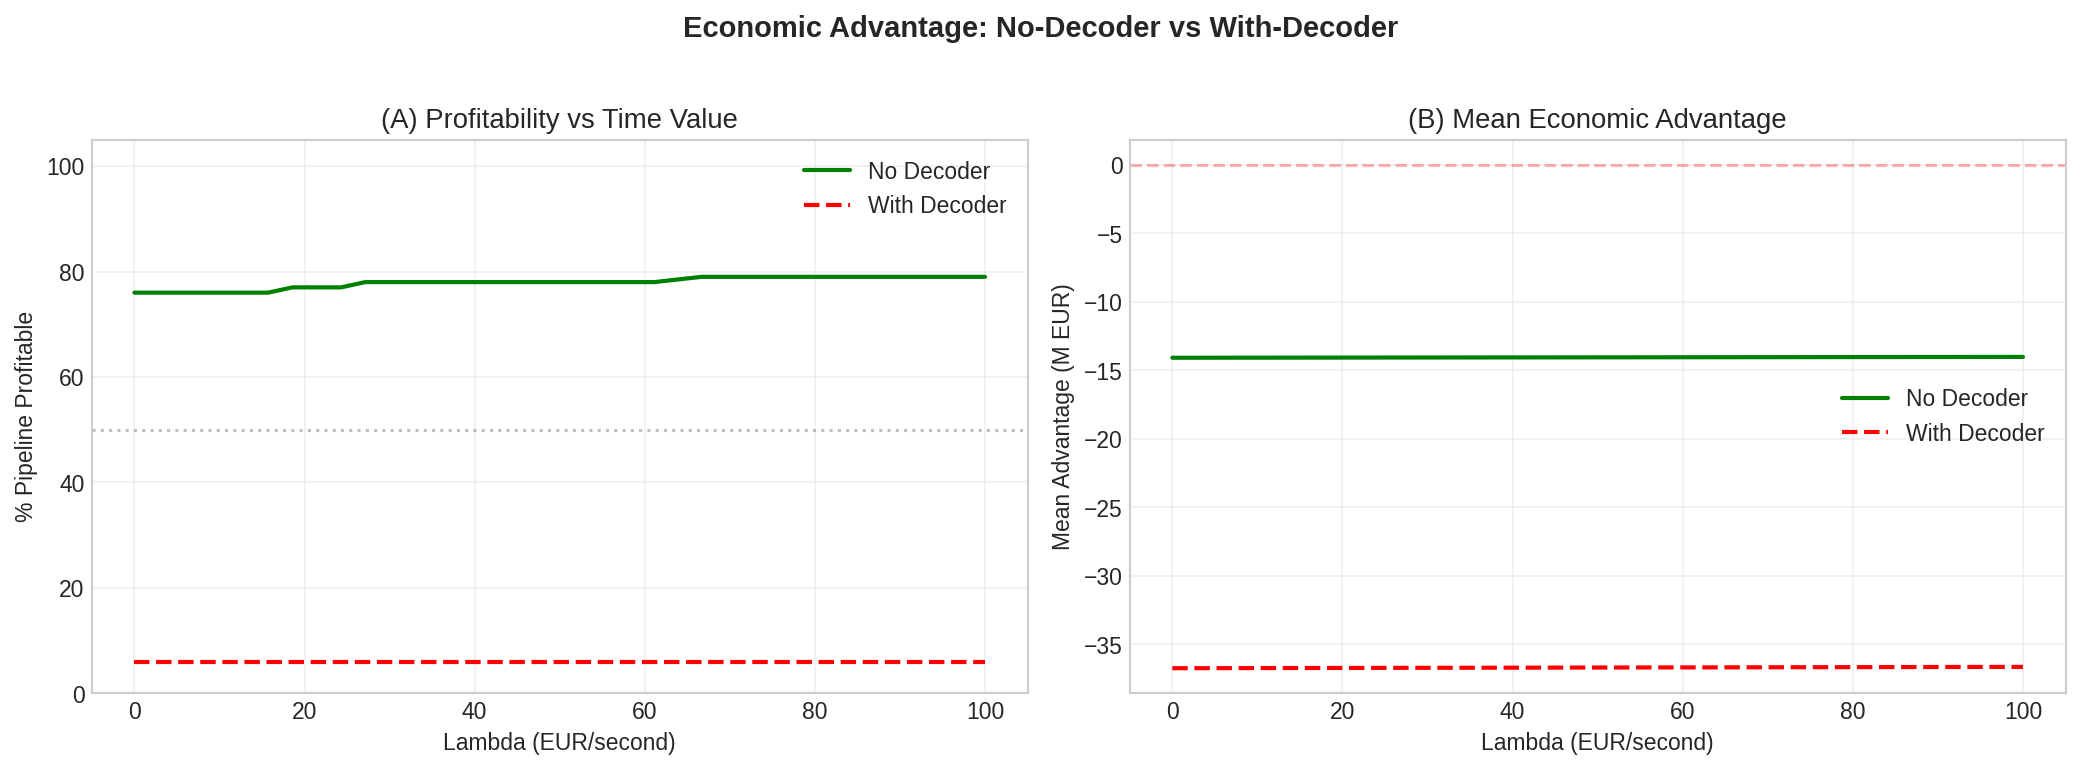


No Decoder: breakeven_50%=0 EUR/s, breakeven_80%=1000 EUR/s
  lambda=10: 76.0% profitable, mean adv=-14.07 MEUR
  lambda=50: 78.0% profitable, mean adv=-14.04 MEUR
  lambda=100: 79.0% profitable, mean adv=-14.01 MEUR

With Decoder: breakeven_50%=1000 EUR/s, breakeven_80%=1000 EUR/s
  lambda=10: 6.0% profitable, mean adv=-36.72 MEUR
  lambda=50: 6.0% profitable, mean adv=-36.68 MEUR
  lambda=100: 6.0% profitable, mean adv=-36.63 MEUR


In [15]:
if HAS_BASELINE:
    from src.eval.economic_advantage import EconomicAdvantageAnalyzer

    econ_nd = EconomicAdvantageAnalyzer(df_nd)
    econ_bl = EconomicAdvantageAnalyzer(df_bl)

    sens_nd = econ_nd.sensitivity_analysis()
    sens_bl = econ_bl.sensitivity_analysis()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(sens_nd['lambda'], sens_nd['pct_profitable'], 'g-', lw=2, label='No Decoder')
    ax.plot(sens_bl['lambda'], sens_bl['pct_profitable'], 'r--', lw=2, label='With Decoder')
    ax.axhline(y=50, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Lambda (EUR/second)')
    ax.set_ylabel('% Pipeline Profitable')
    ax.set_title('(A) Profitability vs Time Value')
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 105)

    ax = axes[1]
    ax.plot(sens_nd['lambda'], sens_nd['mean_advantage'] / 1e6, 'g-', lw=2, label='No Decoder')
    ax.plot(sens_bl['lambda'], sens_bl['mean_advantage'] / 1e6, 'r--', lw=2, label='With Decoder')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel('Lambda (EUR/second)')
    ax.set_ylabel('Mean Advantage (M EUR)')
    ax.set_title('(B) Mean Economic Advantage')
    ax.legend(); ax.grid(True, alpha=0.3)

    fig.suptitle('Economic Advantage: No-Decoder vs With-Decoder',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig3_economic_advantage_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    for label, econ in [('No Decoder', econ_nd), ('With Decoder', econ_bl)]:
        s = econ.compute_summary(lambda_values=[10, 50, 100])
        print(f'\n{label}: breakeven_50%={s["breakeven_lambda_50pct"]:.0f} EUR/s, '
              f'breakeven_80%={s["breakeven_lambda_80pct"]:.0f} EUR/s')
        for k, v in s.items():
            if k.startswith('lambda_'):
                lam = k.replace('lambda_', '')
                print(f'  lambda={lam}: {v["pct_profitable"]:.1f}% profitable, '
                      f'mean adv={v["mean_advantage_eur"]/1e6:.2f} MEUR')

## 12. Conclusion

In [16]:
if HAS_BASELINE:
    print('=' * 80)
    print('ABLATION CONCLUSION')
    print('=' * 80)

    nd_med = df_cmp['nd_cost_gap'].median()
    bl_med = df_cmp['bl_cost_gap'].median()
    nd_mean = df_cmp['nd_cost_gap'].mean()
    bl_mean = df_cmp['bl_cost_gap'].mean()

    if nd_med < bl_med:
        verdict = 'DECODER HURTS: Removing the decoder IMPROVES cost gap.'
        detail = (f'Median cost gap drops from {bl_med:.1f}% to {nd_med:.1f}% '
                  f'({bl_med - nd_med:.1f}pp improvement).')
    elif nd_med > bl_med:
        verdict = 'DECODER HELPS: Removing the decoder WORSENS cost gap.'
        detail = (f'Median cost gap rises from {bl_med:.1f}% to {nd_med:.1f}% '
                  f'({nd_med - bl_med:.1f}pp degradation).')
    else:
        verdict = 'DECODER NEUTRAL: No significant difference in median cost gap.'
        detail = f'Both at {bl_med:.1f}%.'

    print(f'\n  {verdict}')
    print(f'  {detail}')

    nd_t = df_cmp['nd_solve_time'].median()
    bl_t = df_cmp['bl_solve_time'].median()
    if nd_t < bl_t:
        print(f'\n  SPEED: No-decoder is {bl_t - nd_t:.1f}s faster (median).')
    else:
        print(f'\n  SPEED: No-decoder is {nd_t - bl_t:.1f}s slower (median) - '
              f'expected since LP warm-start is lost.')

    nd_win_pct = df_cmp['nd_wins'].mean() * 100
    print(f'\n  No-decoder produces better objective in {nd_win_pct:.0f}% of scenarios.')
    print('=' * 80)
else:
    print('Run evaluation_extreme.ipynb first to get baseline comparison.')

ABLATION CONCLUSION

  DECODER HURTS: Removing the decoder IMPROVES cost gap.
  Median cost gap drops from 119.6% to -0.4% (120.0pp improvement).

  SPEED: No-decoder is 367.5s slower (median) - expected since LP warm-start is lost.

  No-decoder produces better objective in 79% of scenarios.


---

# PART B: Pass-Through Decoder Ablation

**EBM binaries + warm-start, NO binary modifications.**

This isolates the decoder's two effects:
1. **Binary corruption** (flipping EBM decisions via greedy heuristic)
2. **Warm-start benefit** (providing continuous dispatch to initialize LP)

| Mode | Binaries sent to LP | Warm-start? |
|------|-------------------|-------------|
| With Decoder (baseline) | Decoder-modified | Yes |
| No Decoder (Part A) | Raw EBM | No |
| **Pass-Through (Part B)** | **Raw EBM** | **Yes** |

If pass-through beats with-decoder → decoder's binary modifications are the problem.
If pass-through beats no-decoder in speed → warm-start matters even with raw binaries.

In [5]:
# ── Purge cached modules so new code is picked up ──
import importlib, sys, shutil, glob

modules_to_clear = [m for m in sys.modules if m.startswith('src.')]
for m in modules_to_clear:
    del sys.modules[m]
print(f'Cleared {len(modules_to_clear)} cached modules')

pycache_dirs = glob.glob(str(REPO_PATH / 'src/**/__pycache__'), recursive=True)
for d in pycache_dirs:
    shutil.rmtree(d)
print(f'Purged {len(pycache_dirs)} __pycache__ directories')

# Verify decoder_passthrough flag exists
runner_src = (REPO_PATH / 'src/eval/pipeline_runner.py').read_text(encoding='utf-8')
assert 'decoder_passthrough' in runner_src, 'BUG: decoder_passthrough flag missing from pipeline_runner!'
feas_src = (REPO_PATH / 'src/ebm/feasibility.py').read_text(encoding='utf-8')
assert 'decode_passthrough' in feas_src, 'BUG: decode_passthrough method missing from feasibility.py!'
print('decoder_passthrough flag verified')

Cleared 0 cached modules
Purged 0 __pycache__ directories
decoder_passthrough flag verified


In [6]:
from src.eval.pipeline_runner import PipelineConfig, PipelineRunner

PT_OUTPUT_DIR = REPO_PATH / 'outputs/pipeline_eval_extreme_passthrough'
PT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config_pt = PipelineConfig(
    repo_path=str(REPO_PATH),
    encoder_path='outputs/encoders/hierarchical_temporal_v3/best_encoder.pt',
    ebm_path='outputs/ebm_models/ebm_v3/ebm_v3_final.pt',
    node_feature_dim=14,
    hidden_dim=128,
    num_spatial_layers=2,
    num_temporal_layers=4,
    num_heads=8,
    dropout=0.1,
    embed_dim=128,
    n_features=7,
    n_timesteps=24,
    langevin_steps=100,
    step_size=0.05,
    noise_scale=0.5,
    init_temp=1.0,
    final_temp=0.1,
    n_samples=5,
    solver_name='appsi_highs',
    skip_decoder=False,
    decoder_passthrough=True,    # <--- ABLATION: EBM binaries + warm-start
    device=DEVICE,
    seed=42,
)

torch.manual_seed(config_pt.seed)
np.random.seed(config_pt.seed)

print(f'decoder_passthrough = {config_pt.decoder_passthrough}')
print(f'skip_decoder        = {config_pt.skip_decoder}')

runner_pt = PipelineRunner(config_pt)
runner_pt.load_models()

decoder_passthrough = True
skip_decoder        = False
Loading HTE encoder...
  Encoder loaded: 3,185,664 params
Loading EBM v3...
  EBM loaded: 553,729 params
  Sampler ready (infer mode)


In [7]:
import shutil

graphs_dir_pt = PT_OUTPUT_DIR / 'graphs'
if graphs_dir_pt.exists():
    shutil.rmtree(graphs_dir_pt)
    print('Cleared stale graph cache')

results_pt = runner_pt.evaluate_family(
    scenarios_dir=EXTREME_DIR,
    reports_dir=REPORTS_DIR,
    graphs_dir=graphs_dir_pt,
    family_name='extreme_passthrough',
)

runner_pt.save_results(results_pt, PT_OUTPUT_DIR / 'pipeline_eval_extreme_passthrough.pkl')
print(f'\nTotal: {len(results_pt)} scenarios evaluated')


Evaluating 100 scenarios from extreme_passthrough


Pipeline [extreme_passthrough]:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 14. Three-Way Comparison: With-Decoder vs No-Decoder vs Pass-Through

In [ ]:
# Load pass-through results
from src.eval.metrics import compute_eval_metrics, format_metrics_table
from dataclasses import asdict

pt_results_path = PT_OUTPUT_DIR / 'pipeline_eval_extreme_passthrough.pkl'
if pt_results_path.exists():
    pt_pipeline = PipelineRunner.load_results(pt_results_path)
else:
    pt_pipeline = [asdict(r) for r in results_pt]

for r in pt_pipeline:
    r['family'] = 'extreme'

milp_reports_dirs = {'extreme': REPORTS_DIR}
eval_pt = compute_eval_metrics(pt_pipeline, milp_reports_dirs)
df_pt = eval_pt['dataframe']

print(f'Pass-Through DataFrame: {df_pt.shape}')
print(f'Success rate: {df_pt["success"].mean()*100:.1f}%')
print()
print(format_metrics_table(eval_pt['global'], 'Extreme - PASS-THROUGH DECODER'))

In [ ]:
# Build three-way comparison DataFrame
# Reload baseline + no-decoder if needed
BASELINE_PKL = REPO_PATH / 'outputs/pipeline_eval_extreme/pipeline_eval_extreme.pkl'
ND_PKL = REPO_PATH / 'outputs/pipeline_eval_extreme_no_decoder/pipeline_eval_extreme_no_decoder.pkl'

HAS_ALL_THREE = BASELINE_PKL.exists() and ND_PKL.exists()

if HAS_ALL_THREE:
    baseline_pipeline = PipelineRunner.load_results(BASELINE_PKL)
    eval_bl = compute_eval_metrics(baseline_pipeline, milp_reports_dirs)
    df_bl = eval_bl['dataframe']

    nd_pipeline = PipelineRunner.load_results(ND_PKL)
    for r in nd_pipeline:
        r['family'] = 'extreme'
    eval_nd = compute_eval_metrics(nd_pipeline, milp_reports_dirs)
    df_nd = eval_nd['dataframe']

    # Build merged DF
    cols = ['scenario_id', 'pipeline_objective', 'pipeline_solve_time',
            'pipeline_stage', 'cost_gap_pct', 'speedup',
            'time_decoder', 'time_lp_solve', 'milp_objective', 'milp_solve_time']

    df3 = df_bl[cols].copy()
    df3.columns = ['scenario_id', 'bl_obj', 'bl_time', 'bl_stage', 'bl_gap',
                   'bl_speedup', 'bl_t_dec', 'bl_t_lp', 'milp_obj', 'milp_time']

    nd_cols = df_nd[['scenario_id', 'pipeline_objective', 'pipeline_solve_time',
                     'pipeline_stage', 'cost_gap_pct', 'time_decoder', 'time_lp_solve']].copy()
    nd_cols.columns = ['scenario_id', 'nd_obj', 'nd_time', 'nd_stage', 'nd_gap', 'nd_t_dec', 'nd_t_lp']

    pt_cols = df_pt[['scenario_id', 'pipeline_objective', 'pipeline_solve_time',
                     'pipeline_stage', 'cost_gap_pct', 'time_decoder', 'time_lp_solve']].copy()
    pt_cols.columns = ['scenario_id', 'pt_obj', 'pt_time', 'pt_stage', 'pt_gap', 'pt_t_dec', 'pt_t_lp']

    df3 = df3.merge(nd_cols, on='scenario_id', how='inner')
    df3 = df3.merge(pt_cols, on='scenario_id', how='inner')
    print(f'Three-way matched scenarios: {len(df3)}')

    # Who wins?
    df3['best'] = 'tie'
    for idx, row in df3.iterrows():
        objs = {'with_decoder': row['bl_obj'], 'no_decoder': row['nd_obj'], 'passthrough': row['pt_obj']}
        best = min(objs, key=objs.get)
        df3.loc[idx, 'best'] = best

    print(f'\nWin counts (lowest objective):')
    print(df3['best'].value_counts().to_string())
else:
    print('Need all three result sets. Run baseline + no-decoder first.')
    if not BASELINE_PKL.exists():
        print(f'  Missing: {BASELINE_PKL}')
    if not ND_PKL.exists():
        print(f'  Missing: {ND_PKL}')

In [ ]:
if HAS_ALL_THREE:
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))

    # ── Panel A: Cost Gap boxplot ──
    ax = axes[0, 0]
    data_box = [df3['bl_gap'].dropna(), df3['pt_gap'].dropna(), df3['nd_gap'].dropna()]
    labels_box = ['With Decoder', 'Pass-Through', 'No Decoder']
    colors_box = ['#e74c3c', '#3498db', '#2ecc71']
    bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylabel('Cost Gap (%)')
    ax.set_title('(A) Cost Gap Distribution')

    # ── Panel B: Cost Gap paired scatter (PT vs BL) ──
    ax = axes[0, 1]
    ax.scatter(df3['bl_gap'], df3['pt_gap'],
              c='#3498db', s=40, alpha=0.6, edgecolors='white', linewidth=0.5)
    lim = max(df3['bl_gap'].quantile(0.95), df3['pt_gap'].quantile(0.95))
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='x=y')
    ax.set_xlabel('Cost Gap % (WITH decoder)')
    ax.set_ylabel('Cost Gap % (PASS-THROUGH)')
    ax.set_title('(B) Pass-Through vs With-Decoder')
    ax.legend()
    ax.set_xlim(-50, lim * 1.05)
    ax.set_ylim(-50, lim * 1.05)

    # ── Panel C: Cost Gap CDF all three ──
    ax = axes[0, 2]
    for label, col, color, ls in [
        ('With Decoder', 'bl_gap', '#e74c3c', '-'),
        ('Pass-Through', 'pt_gap', '#3498db', '-'),
        ('No Decoder', 'nd_gap', '#2ecc71', '--'),
    ]:
        sorted_vals = np.sort(df3[col].dropna().values)
        cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
        ax.plot(sorted_vals, cdf, color=color, lw=2, linestyle=ls, label=label)
    ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Cost Gap (%)')
    ax.set_ylabel('CDF')
    ax.set_title('(C) Cost Gap CDF (3-way)')
    ax.legend(fontsize=9)
    ax.set_xlim(df3[['bl_gap','pt_gap','nd_gap']].quantile(0.02).min(),
               df3[['bl_gap','pt_gap','nd_gap']].quantile(0.98).max())
    ax.grid(True, alpha=0.3)

    # ── Panel D: Solve Time boxplot ──
    ax = axes[1, 0]
    data_time = [df3['bl_time'].dropna(), df3['pt_time'].dropna(), df3['nd_time'].dropna()]
    bp2 = ax.boxplot(data_time, labels=labels_box, patch_artist=True, showfliers=False)
    for patch, color in zip(bp2['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_ylabel('Solve Time (s)')
    ax.set_title('(D) Solve Time Distribution')

    # ── Panel E: Timing breakdown ──
    ax = axes[1, 1]
    categories = ['Decoder', 'LP Solve']
    bl_means = [df3['bl_t_dec'].mean(), df3['bl_t_lp'].mean()]
    pt_means = [df3['pt_t_dec'].mean(), df3['pt_t_lp'].mean()]
    nd_means = [df3['nd_t_dec'].mean(), df3['nd_t_lp'].mean()]
    x = np.arange(len(categories))
    w = 0.25
    bars1 = ax.bar(x - w, bl_means, w, label='With Decoder', color='#e74c3c', alpha=0.85)
    bars2 = ax.bar(x,     pt_means, w, label='Pass-Through', color='#3498db', alpha=0.85)
    bars3 = ax.bar(x + w, nd_means, w, label='No Decoder', color='#2ecc71', alpha=0.85)
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                    f'{h:.1f}s', ha='center', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylabel('Time (seconds)')
    ax.set_title('(E) Mean Timing Breakdown')
    ax.legend(fontsize=9)

    # ── Panel F: Stage distribution ──
    ax = axes[1, 2]
    stages_order = ['hard_fix', 'repair_20', 'repair_100', 'full_soft', 'failed']
    bl_sc = df3['bl_stage'].value_counts()
    pt_sc = df3['pt_stage'].value_counts()
    nd_sc = df3['nd_stage'].value_counts()
    stage_labels = [s for s in stages_order
                    if s in bl_sc.index or s in pt_sc.index or s in nd_sc.index]
    bl_v = [bl_sc.get(s, 0) for s in stage_labels]
    pt_v = [pt_sc.get(s, 0) for s in stage_labels]
    nd_v = [nd_sc.get(s, 0) for s in stage_labels]
    x = np.arange(len(stage_labels))
    ax.bar(x - w, bl_v, w, label='With Decoder', color='#e74c3c', alpha=0.85)
    ax.bar(x,     pt_v, w, label='Pass-Through', color='#3498db', alpha=0.85)
    ax.bar(x + w, nd_v, w, label='No Decoder', color='#2ecc71', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(stage_labels, rotation=20)
    ax.set_ylabel('Count')
    ax.set_title('(F) LP Stage Distribution')
    ax.legend(fontsize=9)

    fig.suptitle('Three-Way Ablation: With-Decoder vs Pass-Through vs No-Decoder',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(PT_OUTPUT_DIR / 'fig4_three_way_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

In [8]:
if HAS_ALL_THREE:
    print('=' * 90)
    print('THREE-WAY ABLATION SUMMARY')
    print('=' * 90)

    metrics_3 = {
        'Cost Gap % (median)': (df3['bl_gap'].median(), df3['pt_gap'].median(), df3['nd_gap'].median()),
        'Cost Gap % (mean)':   (df3['bl_gap'].mean(),   df3['pt_gap'].mean(),   df3['nd_gap'].mean()),
        'Cost Gap % (P10)':    (np.percentile(df3['bl_gap'].dropna(), 10),
                                np.percentile(df3['pt_gap'].dropna(), 10),
                                np.percentile(df3['nd_gap'].dropna(), 10)),
        'Cost Gap % (P90)':    (np.percentile(df3['bl_gap'].dropna(), 90),
                                np.percentile(df3['pt_gap'].dropna(), 90),
                                np.percentile(df3['nd_gap'].dropna(), 90)),
        'Solve Time (median)': (df3['bl_time'].median(), df3['pt_time'].median(), df3['nd_time'].median()),
        'Solve Time (mean)':   (df3['bl_time'].mean(),   df3['pt_time'].mean(),   df3['nd_time'].mean()),
        'LP Time (mean)':      (df3['bl_t_lp'].mean(),   df3['pt_t_lp'].mean(),   df3['nd_t_lp'].mean()),
        'Decoder Time (mean)': (df3['bl_t_dec'].mean(),   df3['pt_t_dec'].mean(),  df3['nd_t_dec'].mean()),
    }

    print(f'{"Metric":<25s}  {"With Decoder":>14s}  {"Pass-Through":>14s}  {"No Decoder":>14s}')
    print('-' * 90)
    for name, (bl_v, pt_v, nd_v) in metrics_3.items():
        print(f'{name:<25s}  {bl_v:>14.2f}  {pt_v:>14.2f}  {nd_v:>14.2f}')

    print()
    print('Win counts (lowest objective per scenario):')
    vc = df3['best'].value_counts()
    for k, v in vc.items():
        print(f'  {k:<20s}: {v:3d}/{len(df3)} ({v/len(df3)*100:.0f}%)')

    # Diagnosis
    print()
    print('─' * 90)
    bl_med = df3['bl_gap'].median()
    pt_med = df3['pt_gap'].median()
    nd_med = df3['nd_gap'].median()

    if pt_med < bl_med and pt_med <= nd_med:
        print('VERDICT: Pass-through is BEST.')
        print('  → Decoder binary modifications HURT cost gap.')
        print('  → Warm-start HELPS LP speed (vs no-decoder).')
        print('  → Recommended: replace decoder with pass-through in production.')
    elif nd_med < bl_med and nd_med < pt_med:
        print('VERDICT: No-decoder is BEST for cost gap.')
        print('  → Both decoder modifications AND warm-start hurt.')
        print('  → LP works best with raw EBM binaries, cold start.')
    elif bl_med <= pt_med and bl_med <= nd_med:
        print('VERDICT: With-decoder is BEST.')
        print('  → Decoder modifications actually HELP the LP find better solutions.')
        print('  → Current pipeline is already optimal.')
    else:
        print('VERDICT: Results are mixed - check per-scenario analysis above.')

    # Warm-start effect
    pt_t = df3['pt_time'].median()
    nd_t = df3['nd_time'].median()
    bl_t = df3['bl_time'].median()
    print(f'\nWarm-start speed effect:')
    print(f'  Pass-through vs No-decoder: {nd_t - pt_t:+.1f}s median '
          f'({"faster" if pt_t < nd_t else "slower"} with warm-start)')
    print(f'  With-decoder vs Pass-through: {pt_t - bl_t:+.1f}s median '
          f'({"faster" if bl_t < pt_t else "slower"} with decoder binaries)')
    print('=' * 90)

NameError: name 'HAS_ALL_THREE' is not defined